## Yasir Alghamdi | 2230004157
### Lab 6 : Frequency Domain

In [3]:
# Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import data, img_as_float
from skimage import exposure
from skimage.transform import resize

## Filtering in the Frequency Domain

In [4]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256)) # Resize for faster FFT (optional)
# Get image size
M, N = image.shape

In [5]:
# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

In [6]:
# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

In [7]:
# Apply 2D FFT
F = np.fft.fft2(image)

In [8]:
# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

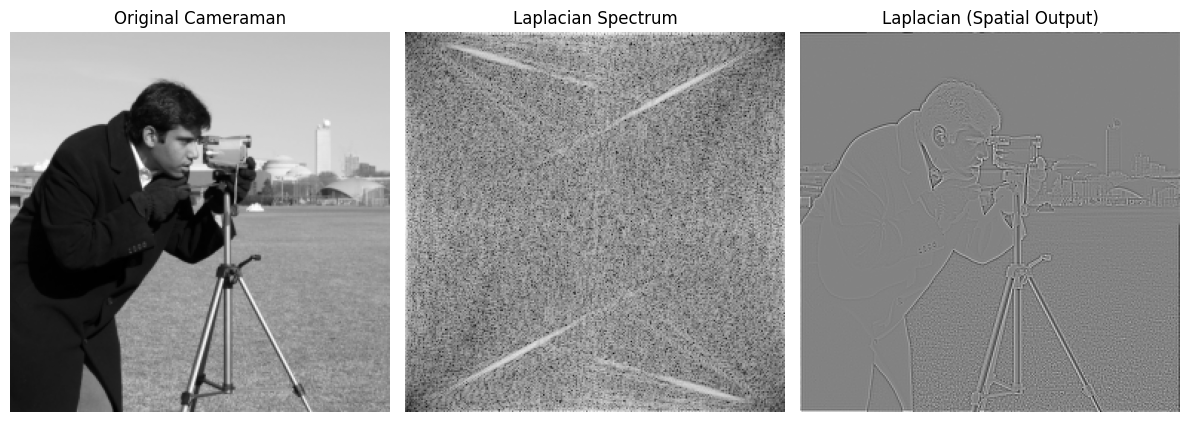

In [9]:
# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real
# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Assessment
Task :
 Using the same Cameraman image, apply the Sobel filter(s) in the frequency domain
and show the results

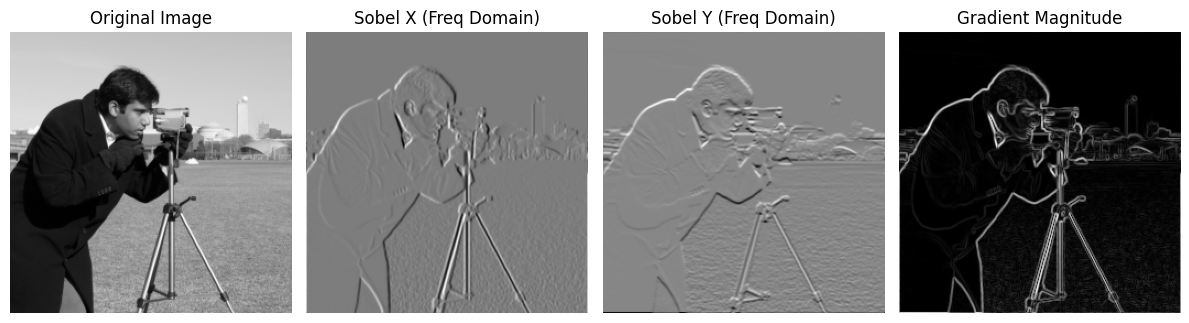

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from scipy.fft import fft2, ifft2, ifftshift

# Load and resize image
image = data.camera()
image = resize(image, (256, 256))

# Get image size
M, N = image.shape

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)

    kh, kw = kernel.shape
    ph, pw = shape

    # Find center coordinates
    cy, cx = ph // 2, pw // 2

    # Insert kernel centered
    padded[
        cy - kh//2 : cy - kh//2 + kh,
        cx - kw//2 : cx - kw//2 + kw
    ] = kernel

    return fft2(ifftshift(padded))

# FFT of image
F_image = fft2(image)

# FFT of Sobel filters
H_sobel_x = center_embed_kernel(sobel_x, (M, N))
H_sobel_y = center_embed_kernel(sobel_y, (M, N))

# Multiply in frequency domain
Gx = F_image * H_sobel_x
Gy = F_image * H_sobel_y

# Inverse FFT
sobel_x_result = np.real(ifft2(Gx))
sobel_y_result = np.real(ifft2(Gy))

# Gradient magnitude
sobel_magnitude = np.sqrt(
    sobel_x_result**2 +
    sobel_y_result**2
)

# Plot results
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sobel_x_result, cmap='gray')
plt.title("Sobel X (Freq Domain)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sobel_y_result, cmap='gray')
plt.title("Sobel Y (Freq Domain)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()